In [ ]:
import pandas as pd
import numpy as np
import pickle
import re
import random
from tqdm import tqdm_notebook


# Loading data

In [2]:
# open text file and read in data
with open("Dailog-dataset.dialogs_dataset", "rb") as f:
  dialogs = pickle.load(f)

In [3]:
len(dialogs)

64776

In [4]:
random.sample(dialogs,10)

['Hello, can you book a table for me for this Friday night?',
 'Can I get a large spinach pizza?',
 "I'dlike dobble olives, add pepper and extra cheese on top",
 "What's the problem?",
 'I need to get something for them to eat',
 'Let me get that',
 ' I appreciate your help',
 "Shoot, I really need to get going and I don't have time to check to see if I can leave the skis here",
 "I also don't want whipped cream",
 "Nope that'll do it, thanks"]

# preprocessing 

In [5]:
# text cleaning
dialogs_clean = []

for i in dialogs:
  # remove everything except alphabets
  i = re.sub("[^a-zA-Z' ]", "", i)
  # convert text to lowercase
  i = i.lower()
  # add cleaned text to the list
  dialogs_clean.append(i)

In [6]:
random.sample(dialogs_clean, 10)

['sure i could use a little extra pick me up',
 'i would like to order something from starbucks to have on the way home can you put in an order for me',
 "it's only me",
 ' may i have to full cost',
 'yes but i prefer to do it myself so just put the cream that the recipe asks for',
 " i've got paperwork to go over with my brother and i don't want the kids interrupting every five minutes",
 'how much for pizza',
 'i need a appointment for my car asap',
 ' wait i think i just want one pump of caramel',
 'what about bahubali movie']

# Word count

In [7]:
# get list of all the words
all_words = " ".join(dialogs_clean).split()

words_dict = {}

# add word-count pair to the dictionary
for word in all_words:   
  # check if the word is already in dictionary 
  if word in words_dict:
    # increment count of word by 1 
    words_dict[word] = words_dict[word] + 1
  else:
    # add the word to dictionary with count 1 
    words_dict[word] = 1

In [8]:
len(words_dict.keys())

11147

In [9]:
# prepare a dataframe
words_df = pd.DataFrame({'word':list(words_dict.keys()), 'count':list(words_dict.values())})

# sort words by their count in increasing order
words_df = words_df.sort_values(by = ['count'])

# reset dataframe index
words_df.reset_index(inplace = True, drop=True)

In [10]:
words_df.tail()

,word,count
11142,you,11909
11143,a,13380
11144,to,14000
11145,the,15406
11146,i,19654


# Find the rare words

In [11]:
# user specified threshold value
rare_thresh = 4

# get percentage of rare words in the vocabulary
rare_words_count = len(words_df[words_df['count'] < rare_thresh]['word'])
total_words = len(words_df) 
rare_dist = rare_words_count / total_words

# coverage percentage of rare words in the corpus
rare_cover = words_df[words_df['count'] < rare_thresh]['count'].sum()/words_df['count'].sum()

In [12]:
print(f"Rare words distribution in the vocabulary: {rare_dist*100:.2f}")
print(f"Rare words coverage in the corpus: {rare_cover*100:.2f}")

Rare words distribution in the vocabulary: 69.03
Rare words coverage in the corpus: 2.27


In [13]:
# extract rare words in a list
rare_words = words_df[words_df['count'] < rare_thresh]['word'].tolist()

In [14]:
len(rare_words)

7695

In [15]:
words_dict["fanta"]

1

In [16]:
#finding pattern to identify rareword and replace them iwht <unk>
import re
pattern = ""
for i in rare_words:
  pattern+= " {} |".format(i)

# removing the last element which is "|"
pattern = pattern[:-1]

# empty list 
dialogs_clean_v2 = []

# replace the rare words with the <unk> token
for d in tqdm_notebook(dialogs_clean):
  text = re.sub(pattern, " <unk> ", d)
  dialogs_clean_v2.append(text)

C:\Users\utsav\anaconda3\envs\nlp_practice\lib\site-packages\ipykernel_launcher.py:14: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  


In [17]:
dialogs_clean_v2[520:530]

['does it serve traditional chinese dessert',
 'how much extra time to reach <unk> ',
 'ok lets reserve a table for dinner at hakkasan',
 'hello i need to get a car please',
 'holiday inn <unk> parkconv <unk> convention center drive <unk> park il',
 'bowling alley <unk> highway <unk> park il',
 'what types of cars does uber have',
 "what's the price difference",
 'ok get me the cheapest please',
 'ok then get me the next level']

# Data Preparation

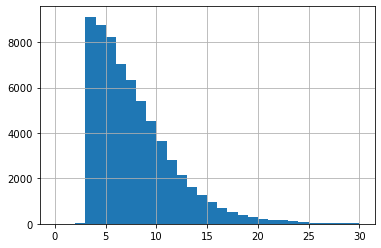

In [18]:
# capture length of all the sequences
text_word_count = []
for i in dialogs_clean_v2:
  text_word_count.append(len(i.split()))
        
# plot the sequence lengths
pd.Series(text_word_count).hist(bins = 30,range=(0,30))

In [24]:
# function to create sequences of equal length
def create_seq(text, seq_len = 5):
      
  sequences = []    
  
  if len(text.split()) > seq_len:
    for i in range(seq_len, len(text.split())):
      #print(i)  
      # select sequence of tokens
      seq = text.split()[i-seq_len:i+1]
      # append sequence to the list
      #print(seq)  
      sequences.append(" ".join(seq))

    return sequences

  else:
    
    return [text]

In [23]:
seqs = [create_seq(i) for i in [dialogs_clean_v2[0]]]

5
['hi', "i'm", 'looking', 'to', 'book', 'a']
6
["i'm", 'looking', 'to', 'book', 'a', 'table']
7
['looking', 'to', 'book', 'a', 'table', 'for']
8
['to', 'book', 'a', 'table', 'for', 'korean']
9
['book', 'a', 'table', 'for', 'korean', 'fod']


In [25]:
dialogs_clean_v2[0].split()

['hi', "i'm", 'looking', 'to', 'book', 'a', 'table', 'for', 'korean', 'fod']

In [26]:
seqs = [create_seq(i) for i in dialogs_clean_v2]

In [28]:
seqs[0]

["hi i'm looking to book a",
 "i'm looking to book a table",
 'looking to book a table for',
 'to book a table for korean',
 'book a table for korean fod']

In [29]:
# merge list-of-lists into a single list
seqs = sum(seqs, [])

In [30]:
seqs

["hi i'm looking to book a",
 "i'm looking to book a table",
 'looking to book a table for',
 'to book a table for korean',
 'book a table for korean fod',
 'somewhere in southern nyc maybe the',
 'in southern nyc maybe the east',
 'southern nyc maybe the east village',
 "we don't want to sit at",
 "don't want to sit at the",
 'want to sit at the bar',
 'to sit at the bar but',
 'sit at the bar but anywhere',
 'at the bar but anywhere else',
 'the bar but anywhere else is',
 'bar but anywhere else is fine',
 'what times are available',
 "yikes we can't do those times",
 'let me check',
 "great let's book that",
 "no that's it just book",
 'hi i would like to see',
 'i would like to see if',
 'would like to see if the',
 'like to see if the movie',
 'to see if the movie what',
 'see if the movie what men',
 'if the movie what men want',
 'the movie what men want is',
 'movie what men want is playing',
 'what men want is playing here',
 'yes for me and a friend',
 'for me and a friend so

In [36]:
# create input and target sequences (x and y)
x = []
y = []

for s in seqs:
  x.append(" ".join(s.split()[:-1]))
  y.append(" ".join(s.split()[1:]))
  #break  

In [32]:
x

["hi i'm looking to book"]

In [33]:
y

["i'm looking to book a"]

In [35]:
seqs[0]

"hi i'm looking to book a"

In [37]:
for i in range(6):
    print(x[i],"---",y[i])

hi i'm looking to book --- i'm looking to book a
i'm looking to book a --- looking to book a table
looking to book a table --- to book a table for
to book a table for --- book a table for korean
book a table for korean --- a table for korean fod
somewhere in southern nyc maybe --- in southern nyc maybe the


# Token integer mapping

In [38]:
# create integer-to-token mapping
int2token = {}
cnt = 1

for w in set(" ".join(dialogs_clean_v2).split()):
  int2token[cnt] = w
  cnt+= 1

# create token-to-integer mapping
token2int = {t: i for i, t in int2token.items()}

# split train test validation

In [39]:
# train-validation split
# input sequences
x_tr = x[:150000]
x_val = x[150000:]

# target sequences
y_tr = y[:150000]
y_val = y[150000:]

# pad sequence

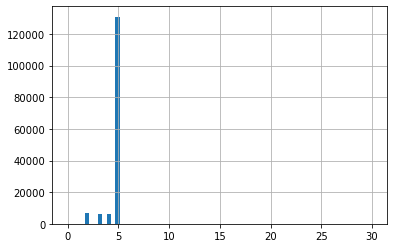

In [40]:
# plot sequence length in train set
text_word_count = []

for i in x_tr:
  text_word_count.append(len(i.split()))

pd.Series(text_word_count).hist(bins = 70,range=(0,30))

In [41]:
# based on the plot above
max_text_len = 5

# function to perform padding
def pad_sequence(seq, n):

  # split input sequence into tokens
  seq = seq.split()
  
  # check if no. of tokens in input sequence is less than 'n'
  if len(seq) < n:
    for i in range(n - len(seq)):
      seq.append("<pad>")

  return " ".join(seq)

# pad text sequences (train set)
x_tr_padded = [pad_sequence(s, max_text_len) for s in x_tr]
y_tr_padded = [pad_sequence(s, max_text_len) for s in y_tr]

# pad text sequences (validation set)
x_val_padded = [pad_sequence(s, max_text_len) for s in x_val]
y_val_padded = [pad_sequence(s, max_text_len) for s in y_val]

In [42]:
x_tr_padded[:20],y_tr_padded[:20]

(["hi i'm looking to book",
  "i'm looking to book a",
  'looking to book a table',
  'to book a table for',
  'book a table for korean',
  'somewhere in southern nyc maybe',
  'in southern nyc maybe the',
  'southern nyc maybe the east',
  "we don't want to sit",
  "don't want to sit at",
  'want to sit at the',
  'to sit at the bar',
  'sit at the bar but',
  'at the bar but anywhere',
  'the bar but anywhere else',
  'bar but anywhere else is',
  'what times are <pad> <pad>',
  "yikes we can't do those",
  'let me <pad> <pad> <pad>',
  "great let's book <pad> <pad>"],
 ["i'm looking to book a",
  'looking to book a table',
  'to book a table for',
  'book a table for korean',
  'a table for korean fod',
  'in southern nyc maybe the',
  'southern nyc maybe the east',
  'nyc maybe the east village',
  "don't want to sit at",
  'want to sit at the',
  'to sit at the bar',
  'sit at the bar but',
  'at the bar but anywhere',
  'the bar but anywhere else',
  'bar but anywhere else is',
 

In [43]:
# update mapping dictionaries
int2token[0] = "<pad>"
token2int["<pad>"] = 0

# set vocabulary size
vocab_size = len(int2token)

# Convert Text sequence to integer sequence

In [44]:
# function to create integer sequences
def get_integer_seq(seq):
  return [token2int[w] for w in seq.split()]

In [120]:
# convert text sequences to integer sequences
x_tr_int = [get_integer_seq(i) for i in x_tr_padded]
y_tr_int = [get_integer_seq(i) for i in y_tr_padded]

x_val_int = [get_integer_seq(i) for i in x_val_padded]
y_val_int = [get_integer_seq(i) for i in y_val_padded]

In [121]:
x_tr_int[:2],y_tr_int[:2]

([[3803, 6170, 4957, 3806, 891], [6170, 4957, 3806, 891, 4127]],
 [[6170, 4957, 3806, 891, 4127], [4957, 3806, 891, 4127, 5121]])

In [122]:
# convert lists into numpy arrays
x_tr_int = np.array(x_tr_int)
y_tr_int = np.array(y_tr_int)

x_val_int = np.array(x_val_int)
y_val_int = np.array(y_val_int)

x_tr_int.shape, y_tr_int.shape, x_val_int.shape, y_val_int.shape

((150000, 5), (150000, 5), (55346, 5), (55346, 5))

In [130]:
x_tr_int = x_tr_int.reshape(-1)
x_val_int = x_val_int.reshape(-1)


y_tr_int = y_tr_int.reshape(-1)
y_val_int = y_val_int.reshape(-1)

# Verify the shapes after reshaping
#print(y_tr_int.shape, y_val_int.shape)

x_tr_int.shape, y_tr_int.shape, x_val_int.shape, y_val_int.shape

((750000,), (750000,), (276730,), (276730,))

# Model Training & Architecture  

In [131]:
import numpy as np
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, LSTM, Dropout, Dense
#Define the WordLSTM model
# def WordLSTM(vocab_size, n_hidden=256, drop_prob=0.3):
#     model = Sequential()
#     model.add(Embedding(input_dim=vocab_size, output_dim=200))
#     model.add(LSTM(units=n_hidden, return_sequences=True))
#     model.add(Dropout(drop_prob))
#     model.add(Dense(units=vocab_size, activation='softmax'))
#     return model

# def WordLSTM(vocab_size, n_hidden=256, drop_prob=0.3):
#     inputs = Input(shape=(None,))
#     embedding = Embedding(input_dim=vocab_size, output_dim=200)(inputs)
#     lstm1, state_h, state_c = LSTM(units=n_hidden, return_sequences=True, return_state=True)(embedding)
#     dropout1 = Dropout(drop_prob)(lstm1)
#     lstm2, _, _ = LSTM(units=n_hidden, return_state=True)(dropout1, initial_state=[state_h, state_c])
#     dropout2 = Dropout(drop_prob)(lstm2)
#     outputs = Dense(units=vocab_size, activation='softmax')(dropout2)
#     model = Model(inputs=inputs, outputs=outputs)
#     return model


model = Sequential()

# Embedding layer
model.add(Embedding(input_dim=vocab_size, output_dim=200))

# LSTM layer
model.add(LSTM(units=256, return_sequences=True, input_shape=(None, 200))) # First LSTM layer
model.add(LSTM(units=256, return_sequences=False)) # Second LSTM layer

# Dropout layer
model.add(Dropout(0.5))

# Fully connected layer
model.add(Dense(units=vocab_size, activation='softmax'))

# Compile the model
#model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Print the summary of the model
#model.summary()

In [132]:
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Embedding, LSTM, Dropout, Dense

# class WordLSTM:
#     def __init__(self, vocab_size, n_hidden=256, n_layers=2, drop_prob=0.3, lr=0.001):
#         self.vocab_size = vocab_size
#         self.n_hidden = n_hidden
#         self.n_layers = n_layers
#         self.drop_prob = drop_prob
#         self.lr = lr

#         self.model = Sequential([
#             Embedding(vocab_size, 200, input_length=None),
#             LSTM(n_hidden, return_sequences=True, return_state=True),
#             Dropout(drop_prob),
#             LSTM(n_hidden, return_sequences=False, return_state=True),
#             Dropout(drop_prob),
#             Dense(vocab_size, activation='softmax')
#         ])

#         self.model.compile(loss='categorical_crossentropy', optimizer='adam')

#     def summary(self):
#         return self.model.summary()

#     def get_model(self):
#         return self.model


In [133]:
#model = WordLSTM(vocab_size)

In [134]:
# Compile the model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy')
# Custom training loop
batch_size = 64
epochs = 10

# Define callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
model_checkpoint = ModelCheckpoint(filepath='best_model_seq.h5', monitor='val_loss', save_best_only=True)

# Train the model
history=model.fit(x_tr_int, y_tr_int, epochs=epochs, 
                  batch_size=batch_size, 
                  validation_data=(x_val_int, y_val_int), verbose=1,
                  callbacks = [early_stopping,model_checkpoint] )

Epoch 1/10
11719/11719 [==============================] - 468s 40ms/step - loss: 4.3636 - val_loss: 4.0691
Epoch 2/10
11719/11719 [==============================] - 463s 40ms/step - loss: 3.9278 - val_loss: 3.9877
Epoch 3/10
11719/11719 [==============================] - 549s 47ms/step - loss: 3.8237 - val_loss: 3.9664
Epoch 4/10
11719/11719 [==============================] - 582s 50ms/step - loss: 3.7667 - val_loss: 3.9504
Epoch 5/10
11719/11719 [==============================] - 589s 50ms/step - loss: 3.7282 - val_loss: 3.9510
Epoch 6/10
11719/11719 [==============================] - 543s 46ms/step - loss: 3.7008 - val_loss: 3.9484
Epoch 7/10
11719/11719 [==============================] - 511s 44ms/step - loss: 3.6801 - val_loss: 3.9526
Epoch 8/10
  720/11719 [>.............................] - ETA: 7:03 - loss: 3.6535

KeyboardInterrupt: 

In [136]:
import numpy as np

# Load weights of best model
path = 'best_model_seq.h5'  # Assuming the weights are saved in HDF5 format
model.load_weights(path)

# Function to generate one token
def predict(model, tkn, h=None):
    # Create input tensor
    x = np.array([[token2int[tkn]]])
    inputs = np.expand_dims(x, axis=0)  # Add batch dimension
    
    # Get the output of the model
    out = model.predict(inputs)
    
    # Get the token probabilities
    p = np.squeeze(out)
    
    sampled_token_index = np.argmax(p)
    
    # Return the encoded value of the predicted token
    return int2token[sampled_token_index], None  # Keras LSTM model doesn't have hidden state

# Function to fetch generated sequence
def sample(model, size=2, seed_text='it is'):
    # Initialize hidden state (not needed for Keras LSTM model)
    h = None

    toks = seed_text.split()

    # Predict next token for each seed token
    for t in toks:
        token, h = predict(model, t, h)
    
    toks.append(token)

    # Predict subsequent tokens
    for i in range(size-1):
        token, h = predict(model, toks[-1], h)
        toks.append(token)

    return ' '.join(toks)

# Seed texts
seeds = ["i want to",
         "how about a cup",
         "i don't want",
         "can you send",
         "my car"]

# Number of tokens to generate
num_toks = 4

# Text generation
for s in seeds:
    # Get generated text from the model
    text_gen = sample(model, num_toks, seed_text=s)
    # Print the result
    print("seed text:", s, ">> output:",text_gen)
    print("\n")


seed text: i want to >> output: i want to order a pizza with


seed text: how about a cup >> output: how about a cup of the <unk> and


seed text: i don't want >> output: i don't want to order a pizza


seed text: can you send >> output: can you send me a pizza with


seed text: my car >> output: my car is the <unk> and




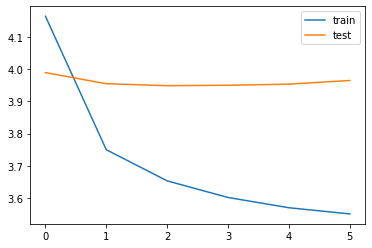

In [137]:
from matplotlib import pyplot 
pyplot.plot(history.history['loss'], label='train') 
pyplot.plot(history.history['val_loss'], label='test') 
pyplot.legend() 
pyplot.show()